# 02 - Exploratory Data Analysis

Goal: establish the raw-data shape, quality risks, relationships, and first business signals before feature engineering or modeling.

## Setup

In [32]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT / "src"))

from datathon_2026_r1.eda import (
    TABLES,
    acquisition_channel_nullness,
    add_customer_cohort,
    build_order_revenue,
    column_summary,
    customer_cohort_summary,
    date_coverage,
    inventory_snapshot_coverage,
    inventory_status_summary,
    inventory_stockout_units_sold_check,
    duplicate_key_report,
    load_all_tables,
    payment_revenue_proxy_check,
    payment_revenue_proxy_summary,
    product_revenue_seasonality,
    relationship_checks,
    revenue_seasonality,
    table_summary,
    write_eda_reports,
)

pd.set_option("display.max_columns", 80)
pd.set_option("display.float_format", "{:.4f}".format)

PLOT_RCPARAMS = {
    "figure.figsize": (11, 6),
    "figure.dpi": 120,
    "savefig.dpi": 150,
    "savefig.bbox": "tight",
    "axes.titlesize": 14,
    "axes.titleweight": "bold",
    "axes.labelsize": 11,
    "axes.grid": True,
    "axes.axisbelow": True,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "grid.alpha": 0.25,
    "grid.linewidth": 0.8,
    "legend.frameon": False,
    "legend.fontsize": 10,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "lines.linewidth": 2.0,
    "lines.markersize": 5,
    "patch.edgecolor": "white",
    "patch.linewidth": 0.5,
}
plt.rcParams.update(PLOT_RCPARAMS)
sns.set_theme(style="whitegrid", palette="Set2", rc=PLOT_RCPARAMS)

## Load Raw Tables

In [33]:
tables = load_all_tables()
list(tables)

['reviews',
 'sales',
 'web_traffic',
 'customers',
 'geography',
 'products',
 'inventory',
 'promotions',
 'sample_submission',
 'order_items',
 'orders',
 'payments',
 'returns',
 'shipments']

In [34]:
summary = table_summary(tables)
summary

,table,rows,columns,missing_cells,missing_pct,duplicate_rows,memory_mb
0,order_items,714669,7,1152816,0.2304,0,78.0027
1,orders,646945,8,0,0.0000,0,162.7759
2,payments,646945,4,0,0.0000,0,50.5635
3,shipments,566067,4,0,0.0000,0,17.2751
4,customers,121930,7,0,0.0000,0,29.0492
5,reviews,113551,7,0,0.0000,0,17.7564
6,inventory,60247,17,0,0.0000,0,16.7565
7,geography,39948,4,0,0.0000,0,6.8635
8,returns,39939,7,0,0.0000,0,6.0754
9,sales,3833,3,0,0.0000,0,0.0879


## Data Dictionary and Missingness

In [35]:
columns = column_summary(tables)
columns.sort_values(["missing_pct", "table", "column"], ascending=[False, True, True]).head(30)

,table,column,dtype,non_null,missing,missing_pct,unique,sample_values
72,order_items,promo_id_2,str,206,714463,0.9997,2,"PROMO-0015, PROMO-0015, PROMO-0015"
59,promotions,applicable_category,str,10,40,0.8000,2,"Streetwear, Outdoor, Streetwear"
71,order_items,promo_id,str,276316,438353,0.6134,50,"PROMO-0006, PROMO-0006, PROMO-0006"
23,customers,acquisition_channel,str,121930,0,0.0000,6,"social_media, email_campaign, organic_search"
22,customers,age_group,str,121930,0,0.0000,5,"35-44, 45-54, 18-24"
19,customers,city,str,121930,0,0.0000,42,"Hai Phong, Hai Phong, Hai Phong"
17,customers,customer_id,int64,121930,0,0.0000,121930,"1, 2, 3"
21,customers,gender,str,121930,0,0.0000,3,"Female, Female, Female"
20,customers,signup_date,datetime64[us],121930,0,0.0000,3941,"2021-12-30 00:00:00, 2013-12-27 00:00:00, 2018..."
18,customers,zip,int64,121930,0,0.0000,31491,"15201, 15201, 15201"


In [36]:
missing_by_table = (
    columns.groupby("table", as_index=False)["missing"].sum()
    .merge(summary[["table", "rows", "columns"]], on="table")
)
missing_by_table["missing_pct"] = missing_by_table["missing"] / (missing_by_table["rows"] * missing_by_table["columns"])
missing_by_table.sort_values("missing_pct", ascending=False)

,table,missing,rows,columns,missing_pct
3,order_items,1152816,714669,7,0.2304
7,promotions,40,50,10,0.0800
1,geography,0,39948,4,0.0000
2,inventory,0,60247,17,0.0000
4,orders,0,646945,8,0.0000
0,customers,0,121930,7,0.0000
5,payments,0,646945,4,0.0000
6,products,0,2412,8,0.0000
8,returns,0,39939,7,0.0000
9,reviews,0,113551,7,0.0000


## Customer Cohorts and Acquisition Quality

In [37]:
customers = add_customer_cohort(tables["customers"])
customer_cohorts = customer_cohort_summary(customers)
customers[["customer_id", "signup_date", "cohort_date", "acquisition_channel"]].head()

,customer_id,signup_date,cohort_date,acquisition_channel
0,1,2021-12-30,2021-12-01,social_media
1,2,2013-12-27,2013-12-01,email_campaign
2,3,2018-07-24,2018-07-01,organic_search
3,4,2017-11-29,2017-11-01,referral
4,5,2022-09-23,2022-09-01,organic_search


In [38]:
customer_cohorts.tail(12)

,cohort_date,new_customers,signup_year,cumulative_customers
120,2022-01-01,1748,2022,102575
121,2022-02-01,1520,2022,104095
122,2022-03-01,1742,2022,105837
123,2022-04-01,1669,2022,107506
124,2022-05-01,1832,2022,109338
125,2022-06-01,1749,2022,111087
126,2022-07-01,1714,2022,112801
127,2022-08-01,1761,2022,114562
128,2022-09-01,1782,2022,116344
129,2022-10-01,1847,2022,118191


,signup_year,new_customers,yoy_new_customer_change_pct
0,2012,957,NaN
1,2013,2989,2.1233
2,2014,5034,0.6842
3,2015,7133,0.4170
4,2016,9202,0.2901
5,2017,11078,0.2039
6,2018,13011,0.1745
7,2019,15058,0.1573
8,2020,17211,0.1430
9,2021,19154,0.1129


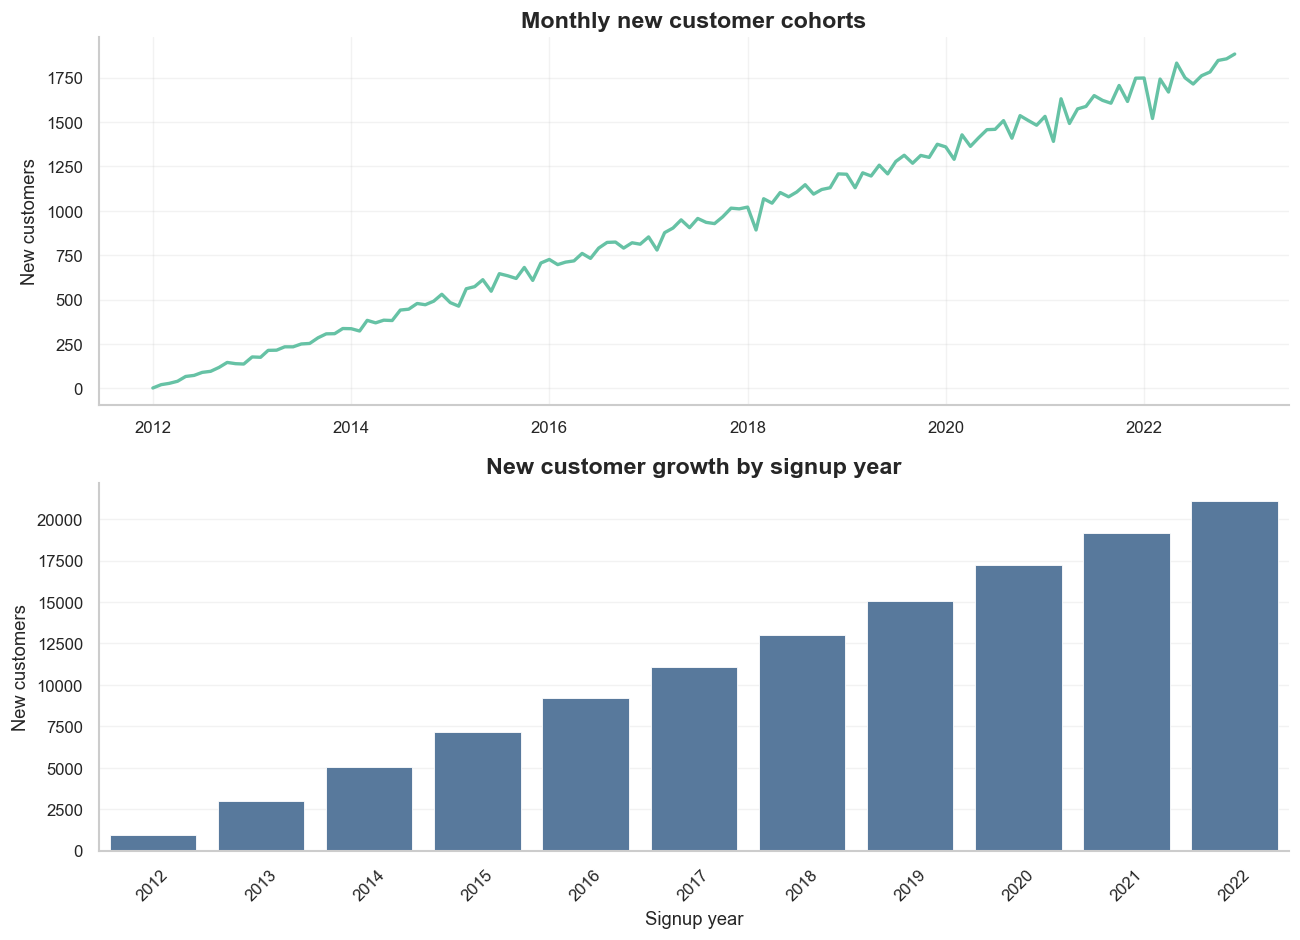

In [39]:
fig, axes = plt.subplots(2, 1, figsize=(11, 8), sharex=False)
sns.lineplot(data=customer_cohorts, x="cohort_date", y="new_customers", ax=axes[0])
axes[0].set_title("Monthly new customer cohorts")
axes[0].set_xlabel("")
axes[0].set_ylabel("New customers")

yearly_customer_growth = (
    customer_cohorts.groupby("signup_year", as_index=False)
    .agg(new_customers=("new_customers", "sum"))
    .sort_values("signup_year")
)
yearly_customer_growth["yoy_new_customer_change_pct"] = yearly_customer_growth["new_customers"].pct_change()
sns.barplot(data=yearly_customer_growth, x="signup_year", y="new_customers", ax=axes[1], color="#4C78A8")
axes[1].set_title("New customer growth by signup year")
axes[1].set_xlabel("Signup year")
axes[1].set_ylabel("New customers")
axes[1].tick_params(axis="x", rotation=45)
plt.tight_layout()
yearly_customer_growth

In [40]:
acquisition_quality = acquisition_channel_nullness(customers)
channel_mix = (
    customers.assign(acquisition_channel=customers["acquisition_channel"].fillna("Missing"))
    .groupby("acquisition_channel", as_index=False)
    .agg(customers=("customer_id", "nunique"))
    .sort_values("customers", ascending=False)
)
display(acquisition_quality)
channel_mix

,column,rows,missing_rows,blank_rows,missing_or_blank_rows,missing_or_blank_pct,unique_non_null_channels
0,acquisition_channel,121930,0,0,0,0.0000,6


,acquisition_channel,customers
2,organic_search,36450
5,social_media,24448
3,paid_search,24285
1,email_campaign,14674
4,referral,12270
0,direct,9803


## Key and Relationship Checks

In [41]:
duplicate_key_report(tables)

,table,key_columns,rows,duplicate_key_rows,duplicate_key_pct
0,reviews,review_id,113551,0,0.0000
1,customers,customer_id,121930,0,0.0000
2,products,product_id,2412,0,0.0000
3,promotions,promo_id,50,0,0.0000
4,orders,order_id,646945,0,0.0000
5,returns,return_id,39939,0,0.0000


In [42]:
relationship_checks(tables).sort_values("unmatched_pct", ascending=False)

,left,right,checked_rows,unmatched_rows,unmatched_pct
0,orders.customer_id,customers.customer_id,646945,0,0.0000
1,orders.zip,geography.zip,646945,0,0.0000
2,order_items.order_id,orders.order_id,714669,0,0.0000
3,order_items.product_id,products.product_id,714669,0,0.0000
4,payments.order_id,orders.order_id,646945,0,0.0000
5,shipments.order_id,orders.order_id,566067,0,0.0000
6,returns.order_id,orders.order_id,39939,0,0.0000
7,returns.product_id,products.product_id,39939,0,0.0000
8,reviews.order_id,orders.order_id,113551,0,0.0000
9,reviews.product_id,products.product_id,113551,0,0.0000


## Date Coverage

In [43]:
coverage = date_coverage(tables)
coverage

,table,date_column,min_date,max_date,missing_dates
0,reviews,review_date,2012-07-10,2022-12-31,0
1,sales,Date,2012-07-04,2022-12-31,0
2,web_traffic,date,2013-01-01,2022-12-31,0
3,customers,signup_date,2012-01-17,2022-12-31,0
4,inventory,snapshot_date,2012-07-31,2022-12-31,0
5,promotions,start_date,2013-01-31,2022-11-18,0
6,promotions,end_date,2013-03-01,2022-12-31,0
7,sample_submission,Date,2023-01-01,2024-07-01,0
8,orders,order_date,2012-07-04,2022-12-31,0
9,returns,return_date,2012-07-11,2022-12-31,0


## Inventory Health

In [44]:
inventory = tables["inventory"]
inventory_coverage = inventory_snapshot_coverage(inventory)
missing_inventory_months = inventory_coverage.loc[~inventory_coverage["has_snapshot"]]
display(inventory_coverage.head())
display(inventory_coverage.tail())
missing_inventory_months

,month,has_snapshot,snapshot_dates,snapshot_rows,unique_products
0,2012-07-01,True,1,395,395
1,2012-08-01,True,1,423,423
2,2012-09-01,True,1,424,424
3,2012-10-01,True,1,437,437
4,2012-11-01,True,1,411,411


,month,has_snapshot,snapshot_dates,snapshot_rows,unique_products
121,2022-08-01,True,1,461,461
122,2022-09-01,True,1,419,419
123,2022-10-01,True,1,409,409
124,2022-11-01,True,1,376,376
125,2022-12-01,True,1,424,424


,month,has_snapshot,snapshot_dates,snapshot_rows,unique_products


In [45]:
inventory_status = inventory_status_summary(inventory)
inventory_status.tail(12)

,month,rows,unique_products,stockout_products,overstock_products,reorder_products,avg_fill_rate,median_fill_rate,avg_stock_on_hand,total_units_received,total_units_sold,stockout_rate,overstock_rate,reorder_rate
114,2022-01-01,388,388,226,318,0,0.9693,0.9667,258.5876,2607,2305,0.5825,0.8196,0.0000
115,2022-02-01,426,426,290,319,0,0.9643,0.9667,249.7770,3713,3270,0.6808,0.7488,0.0000
116,2022-03-01,474,474,323,345,0,0.9628,0.9667,235.5992,5911,5096,0.6814,0.7278,0.0000
117,2022-04-01,496,496,348,338,0,0.9579,0.9667,235.8407,7443,6360,0.7016,0.6815,0.0000
118,2022-05-01,485,485,321,346,0,0.9647,0.9667,241.1113,6401,5509,0.6619,0.7134,0.0000
119,2022-06-01,464,464,313,323,0,0.9639,0.9667,236.4224,6693,5759,0.6746,0.6961,0.0000
120,2022-07-01,410,410,284,307,0,0.9650,0.9667,248.9829,4746,4123,0.6927,0.7488,0.0000
121,2022-08-01,461,461,301,335,0,0.9652,0.9667,227.5141,5499,4772,0.6529,0.7267,0.0000
122,2022-09-01,419,419,269,340,0,0.9670,0.9667,256.1074,3868,3360,0.6420,0.8115,0.0000
123,2022-10-01,409,409,268,351,0,0.9618,0.9667,254.9022,3309,2908,0.6553,0.8582,0.0000


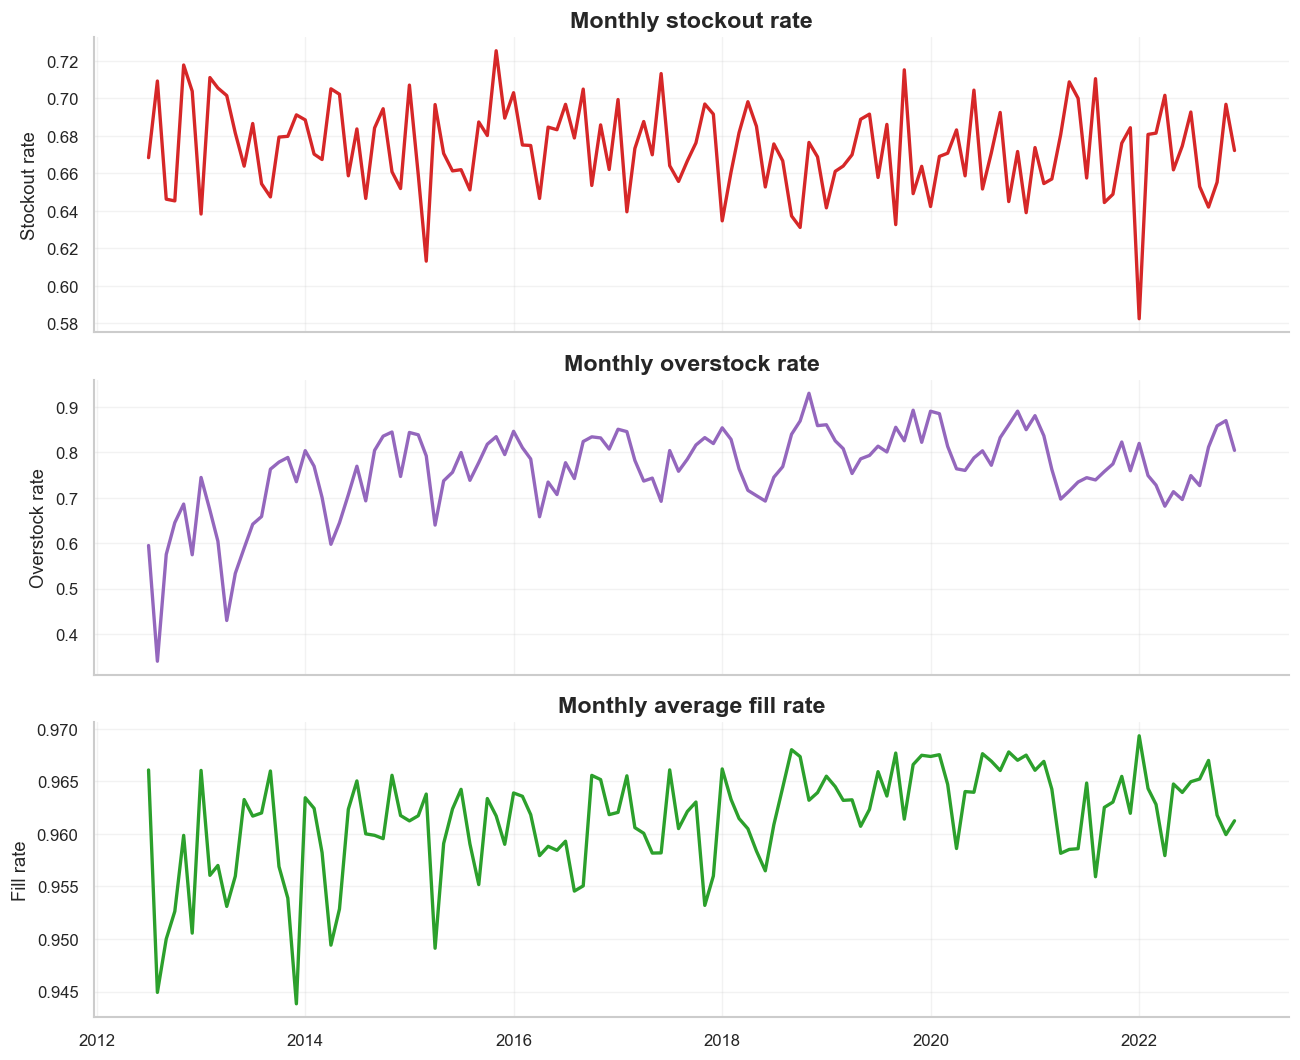

In [46]:
fig, axes = plt.subplots(3, 1, figsize=(11, 9), sharex=True)
sns.lineplot(data=inventory_status, x="month", y="stockout_rate", ax=axes[0], color="#D62728")
axes[0].set_title("Monthly stockout rate")
axes[0].set_ylabel("Stockout rate")
axes[0].set_xlabel("")

sns.lineplot(data=inventory_status, x="month", y="overstock_rate", ax=axes[1], color="#9467BD")
axes[1].set_title("Monthly overstock rate")
axes[1].set_ylabel("Overstock rate")
axes[1].set_xlabel("")

sns.lineplot(data=inventory_status, x="month", y="avg_fill_rate", ax=axes[2], color="#2CA02C")
axes[2].set_title("Monthly average fill rate")
axes[2].set_ylabel("Fill rate")
axes[2].set_xlabel("")
plt.tight_layout()

In [47]:
stock_status_by_group = (
    inventory.groupby(["category", "segment"], as_index=False)
    .agg(
        rows=("product_id", "size"),
        stockout_products=("stockout_flag", "sum"),
        overstock_products=("overstock_flag", "sum"),
        avg_fill_rate=("fill_rate", "mean"),
        avg_days_of_supply=("days_of_supply", "mean"),
        total_units_sold=("units_sold", "sum"),
    )
)
stock_status_by_group["stockout_rate"] = stock_status_by_group["stockout_products"] / stock_status_by_group["rows"]
stock_status_by_group["overstock_rate"] = stock_status_by_group["overstock_products"] / stock_status_by_group["rows"]
stock_status_by_group.sort_values(["stockout_rate", "overstock_rate"], ascending=False)

,category,segment,rows,stockout_products,overstock_products,avg_fill_rate,avg_days_of_supply,total_units_sold,stockout_rate,overstock_rate
2,GenZ,Trendy,4674,3192,3348,0.9617,718.8122,48695,0.6829,0.7163
5,Streetwear,Balanced,6622,4496,4794,0.9581,837.8431,135119,0.6789,0.7240
4,Outdoor,Premium,3182,2160,2512,0.9616,822.4648,40874,0.6788,0.7894
0,Casual,Activewear,422,284,207,0.9525,199.3865,1824,0.6730,0.4905
7,Streetwear,Performance,7673,5162,5730,0.9612,745.6083,125619,0.6727,0.7468
3,Outdoor,Activewear,17868,12017,14297,0.9629,1112.7128,296636,0.6725,0.8001
6,Streetwear,Everyday,13598,9143,10613,0.9598,1113.7547,236495,0.6724,0.7805
8,Streetwear,Standard,3127,2082,2105,0.9646,353.3401,14234,0.6658,0.6732
1,Casual,All-weather,3081,2035,2336,0.9631,494.7097,29378,0.6605,0.7582


In [48]:
stockout_units_sold_check = inventory_stockout_units_sold_check(inventory)
stockout_violations = inventory.loc[
    inventory["stockout_flag"].astype(bool) & inventory["units_sold"].fillna(0).ne(0),
    ["snapshot_date", "product_id", "product_name", "category", "segment", "stockout_flag", "units_sold", "stock_on_hand", "fill_rate"],
]
display(stockout_units_sold_check)
stockout_violations.head(20)

,stockout_rows,stockout_rows_with_units_sold_gt_0,stockout_rows_with_units_sold_not_0,rule_holds_pct,mean_units_sold_when_stockout,median_units_sold_when_stockout,max_units_sold_when_stockout
0,40571,40571,40571,0.0000,15.4861,6.0000,670.0000


,snapshot_date,product_id,product_name,category,segment,stockout_flag,units_sold,stock_on_hand,fill_rate
0,2022-10-31,1,DragonWear MA-01,Casual,All-weather,1,1,3,0.9333
1,2022-11-30,1,DragonWear MA-01,Casual,All-weather,1,1,3,0.9667
2,2022-12-31,1,DragonWear MA-01,Casual,All-weather,1,1,3,0.9667
3,2016-04-30,3,DragonWear MA-03,Casual,All-weather,1,11,35,0.9333
4,2016-05-31,3,DragonWear MA-03,Casual,All-weather,1,10,36,0.9667
5,2016-06-30,3,DragonWear MA-03,Casual,All-weather,1,7,37,0.9333
6,2016-07-31,3,DragonWear MA-03,Casual,All-weather,1,9,39,0.9333
9,2016-10-31,3,DragonWear MA-03,Casual,All-weather,1,6,41,0.9667
11,2016-12-31,3,DragonWear MA-03,Casual,All-weather,1,11,45,0.9333
13,2017-02-28,3,DragonWear MA-03,Casual,All-weather,1,14,50,0.9333


## First Business Signals

In [49]:
orders = tables["orders"]
order_items = tables["order_items"]
products = tables["products"]
returns = tables["returns"]
payments = tables["payments"]
shipments = tables["shipments"]

order_items_enriched = order_items.merge(products, on="product_id", how="left", suffixes=("", "_product"))
order_items_enriched["gross_item_value"] = order_items_enriched["quantity"] * order_items_enriched["unit_price"]
order_items_enriched["net_item_value"] = order_items_enriched["gross_item_value"] - order_items_enriched["discount_amount"].fillna(0)
order_items_enriched["item_cogs"] = order_items_enriched["quantity"] * order_items_enriched["cogs"]

order_revenue = (
    order_items_enriched.groupby("order_id", as_index=False)
    .agg(
        items=("quantity", "sum"),
        gross_revenue=("gross_item_value", "sum"),
        discount=("discount_amount", "sum"),
        net_revenue=("net_item_value", "sum"),
        item_cogs=("item_cogs", "sum"),
    )
)
orders_enriched = orders.merge(order_revenue, on="order_id", how="left")
orders_enriched.head()

,order_id,order_date,customer_id,zip,order_status,payment_method,device_type,order_source,items,gross_revenue,discount,net_revenue,item_cogs
0,1,2012-07-04,58578,1109,delivered,credit_card,desktop,paid_search,7,7967.5400,0.0000,7967.5400,7376.5861
1,2,2012-07-04,58621,1330,returned,cod,mobile,paid_search,7,71163.7500,0.0000,71163.7500,62913.9296
2,3,2012-07-04,58811,1473,delivered,credit_card,desktop,direct,3,33660.9900,0.0000,33660.9900,30273.0368
3,4,2012-07-04,59453,2360,delivered,credit_card,desktop,referral,5,53196.2500,0.0000,53196.2500,46027.1524
4,6,2012-07-06,57821,2886,delivered,paypal,mobile,email_campaign,1,1597.8400,0.0000,1597.8400,1048.6964


In [50]:
monthly_orders = (
    orders_enriched.assign(month=orders_enriched["order_date"].dt.to_period("M").dt.to_timestamp())
    .groupby("month", as_index=False)
    .agg(orders=("order_id", "nunique"), revenue=("net_revenue", "sum"), cogs=("item_cogs", "sum"))
)
monthly_orders["gross_margin"] = monthly_orders["revenue"] - monthly_orders["cogs"]
monthly_orders.tail()

,month,orders,revenue,cogs,gross_margin
121,2022-08-01,3274,113536006.9100,94033378.3350,19502628.5750
122,2022-09-01,2643,77816856.5500,78395242.2586,-578385.7086
123,2022-10-01,2097,75137019.0800,61969893.7692,13167125.3108
124,2022-11-01,1703,48420115.6500,47098021.4983,1322094.1517
125,2022-12-01,2400,42089159.8100,53489673.4420,-11400513.6320


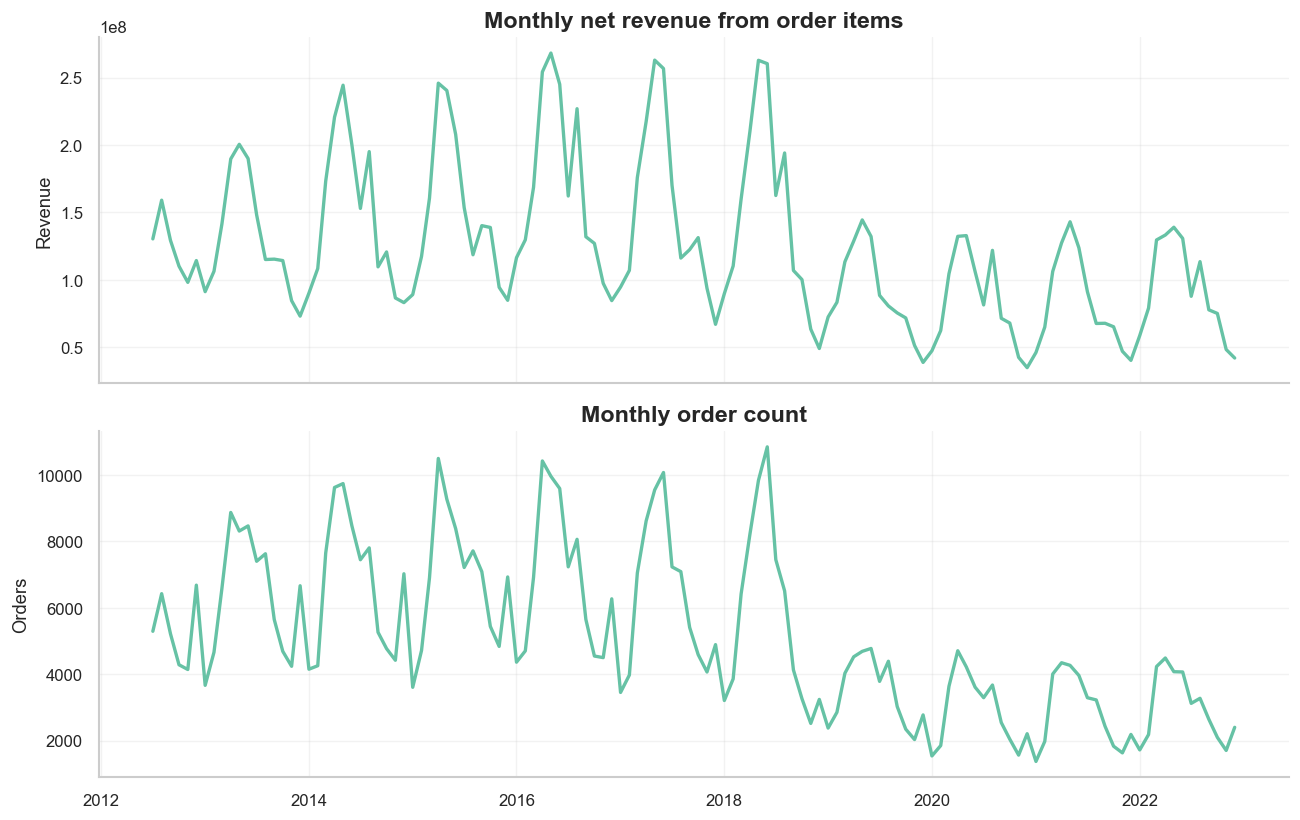

In [51]:
fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True)
sns.lineplot(data=monthly_orders, x="month", y="revenue", ax=axes[0])
axes[0].set_title("Monthly net revenue from order items")
axes[0].set_xlabel("")
axes[0].set_ylabel("Revenue")
sns.lineplot(data=monthly_orders, x="month", y="orders", ax=axes[1])
axes[1].set_title("Monthly order count")
axes[1].set_xlabel("")
axes[1].set_ylabel("Orders")
plt.tight_layout()

## Revenue Seasonality

In [52]:
seasonal_revenue = revenue_seasonality(orders_enriched)
seasonal_revenue.tail(12)

,year,month,month_name,orders,revenue,cogs,gross_margin
114,2022,1,Jan,1719,58731345.8900,50851459.6196,7879886.2704
115,2022,2,Feb,2182,79103095.5000,65285573.1639,13817522.3361
116,2022,3,Mar,4231,129591722.5300,121666971.0251,7924751.5049
117,2022,4,Apr,4489,133254494.7900,124361629.9605,8892864.8295
118,2022,5,May,4076,139027887.1600,113951506.2542,25076380.9058
119,2022,6,Jun,4068,130756674.0700,117710885.8978,13045788.1722
120,2022,7,Jul,3122,87842718.5600,91605928.7213,-3763210.1613
121,2022,8,Aug,3274,113536006.9100,94033378.3350,19502628.5750
122,2022,9,Sep,2643,77816856.5500,78395242.2586,-578385.7086
123,2022,10,Oct,2097,75137019.0800,61969893.7692,13167125.3108


,month,month_name,avg_revenue,median_revenue,avg_orders,avg_gross_margin
0,1,Jan,79643046.9170,89470325.5100,2945.0000,14430818.7946
1,2,Feb,96929115.9220,106716830.2400,3503.1000,17284077.4580
2,3,Mar,143376127.7100,150736915.9200,5744.0000,12232664.0003
3,4,Apr,185950466.5130,199864990.3700,7433.5000,20174362.6498
4,5,May,203837906.8340,220442397.8450,7394.3000,40672118.5114
5,6,Jun,185284467.0730,195084260.2750,7227.0000,23556733.7174
6,7,Jul,129920204.7000,148259913.6400,5706.9091,949711.3221
7,8,Aug,137177599.7809,118633995.6500,5982.8182,2377886.7808
8,9,Sep,104433167.7218,109687126.8000,4459.4545,3096049.7292
9,10,Oct,102085792.5400,110185694.4500,3627.5455,19789670.9458


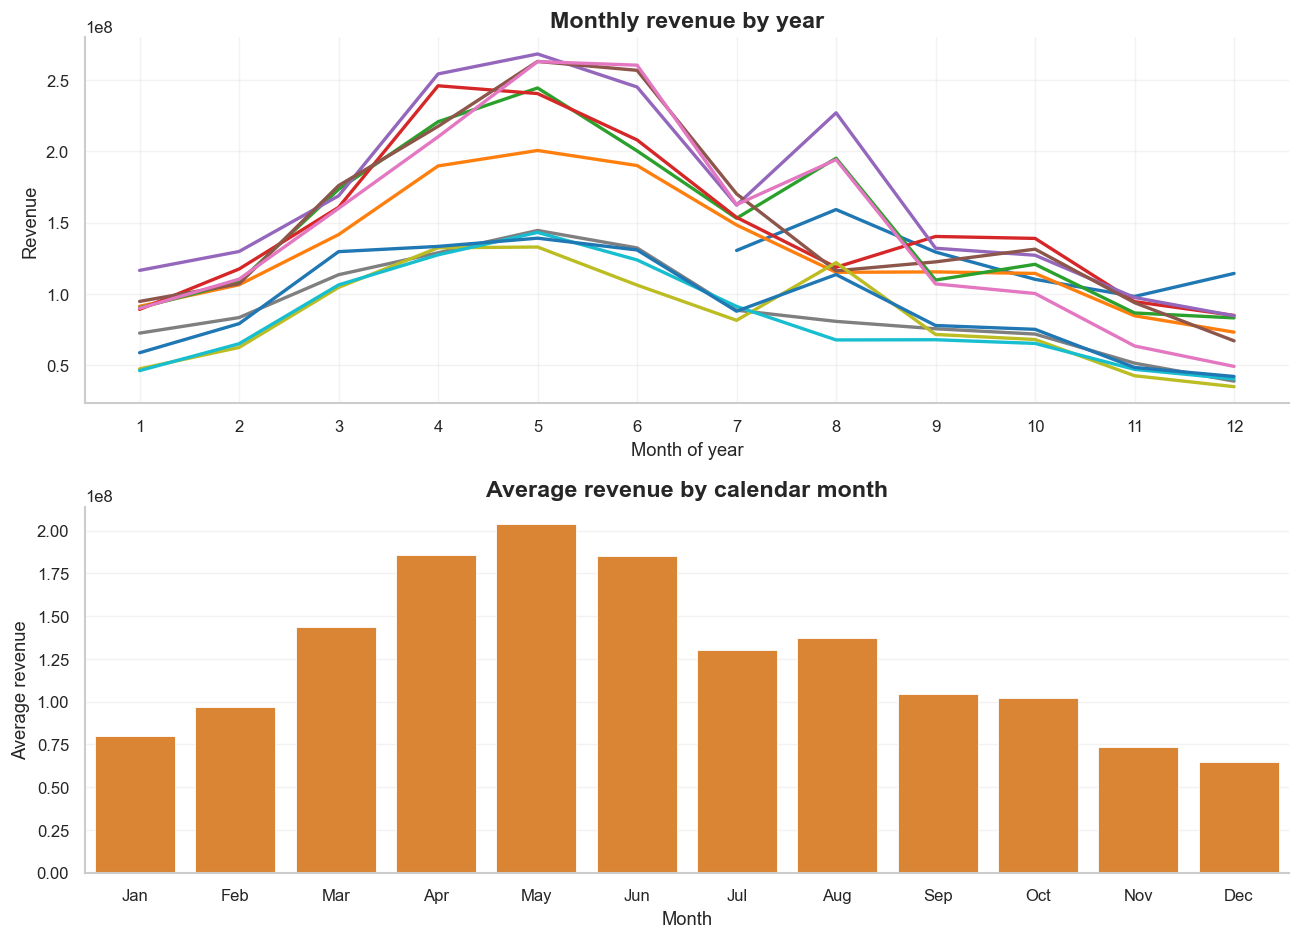

In [53]:
month_order = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
seasonal_profile = (
    seasonal_revenue.groupby(["month", "month_name"], as_index=False)
    .agg(
        avg_revenue=("revenue", "mean"),
        median_revenue=("revenue", "median"),
        avg_orders=("orders", "mean"),
        avg_gross_margin=("gross_margin", "mean"),
    )
    .sort_values("month")
)
seasonal_profile["month_name"] = pd.Categorical(seasonal_profile["month_name"], categories=month_order, ordered=True)

fig, axes = plt.subplots(2, 1, figsize=(11, 8))
sns.lineplot(data=seasonal_revenue, x="month", y="revenue", hue="year", palette="tab10", legend=False, ax=axes[0])
axes[0].set_title("Monthly revenue by year")
axes[0].set_xlabel("Month of year")
axes[0].set_ylabel("Revenue")
axes[0].set_xticks(range(1, 13))

sns.barplot(data=seasonal_profile, x="month_name", y="avg_revenue", ax=axes[1], color="#F58518")
axes[1].set_title("Average revenue by calendar month")
axes[1].set_xlabel("Month")
axes[1].set_ylabel("Average revenue")
plt.tight_layout()
seasonal_profile

,month,month_name,product_group,avg_revenue,avg_quantity
42,5,May,Streetwear / Everyday,71420600.2070,10561.9000
51,6,Jun,Streetwear / Everyday,66455267.9580,10549.2000
33,4,Apr,Streetwear / Everyday,64046932.7820,10358.6000
41,5,May,Streetwear / Balanced,59656449.6280,5055.6000
50,6,Jun,Streetwear / Balanced,56044906.4680,5187.1000
32,4,Apr,Streetwear / Balanced,54879591.2620,5197.5000
60,7,Jul,Streetwear / Everyday,47748836.7027,8488.2727
24,3,Mar,Streetwear / Everyday,47227311.9670,7503.9000
69,8,Aug,Streetwear / Everyday,44542336.3227,8236.0000
23,3,Mar,Streetwear / Balanced,44207898.1840,4225.4000


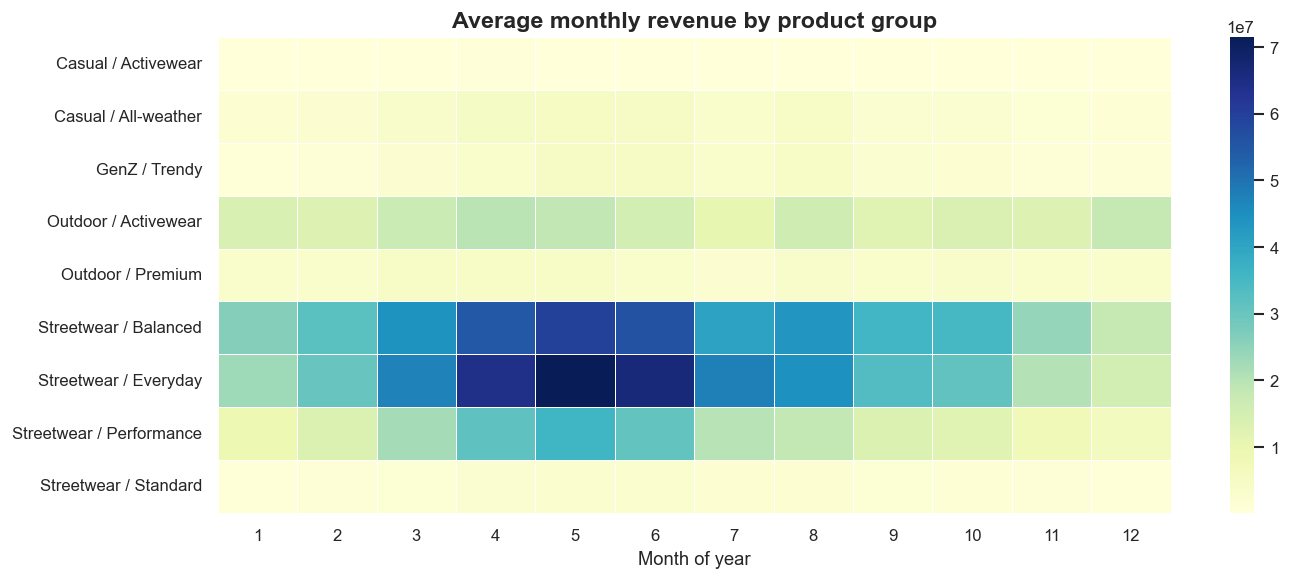

In [54]:
product_seasonality = product_revenue_seasonality(tables)
product_seasonality["product_group"] = product_seasonality["category"] + " / " + product_seasonality["segment"]
product_month_profile = (
    product_seasonality.groupby(["month", "month_name", "product_group"], as_index=False)
    .agg(avg_revenue=("revenue", "mean"), avg_quantity=("quantity", "mean"))
)
product_month_pivot = product_month_profile.pivot(index="product_group", columns="month", values="avg_revenue")

plt.figure(figsize=(12, 5))
sns.heatmap(product_month_pivot, cmap="YlGnBu", linewidths=0.5)
plt.title("Average monthly revenue by product group")
plt.xlabel("Month of year")
plt.ylabel("")
plt.tight_layout()
product_month_profile.sort_values("avg_revenue", ascending=False).head(20)

In [55]:
category_sales = (
    order_items_enriched.groupby(["category", "segment"], as_index=False)
    .agg(quantity=("quantity", "sum"), revenue=("net_item_value", "sum"), cogs=("item_cogs", "sum"))
)
category_sales["gross_margin"] = category_sales["revenue"] - category_sales["cogs"]
category_sales.sort_values("revenue", ascending=False).head(20)

,category,segment,quantity,revenue,cogs,gross_margin
6,Streetwear,Everyday,819449,5147454916.6100,4615280157.2905,532174759.3195
5,Streetwear,Balanced,464217,4900317965.8900,4469081905.2294,431236060.6606
7,Streetwear,Performance,435685,2285029332.1800,2111335495.5235,173693836.6565
3,Outdoor,Activewear,1030535,1899184896.3200,1658737030.4338,240447865.8862
4,Outdoor,Premium,139465,454211900.5400,427625674.4036,26586226.1364
1,Casual,All-weather,101147,408765115.4100,380916033.4762,27849081.9338
2,GenZ,Trendy,166848,328710175.6500,277873798.1513,50836377.4987
8,Streetwear,Standard,49475,225674884.4900,196972029.5803,28702854.9097
0,Casual,Activewear,6322,31520078.3400,25628395.0393,5891683.3007


In [56]:
returns_summary = (
    returns.groupby("return_reason", as_index=False)
    .agg(return_rows=("return_id", "count"), returned_units=("return_quantity", "sum"), refund_amount=("refund_amount", "sum"))
    .sort_values("return_rows", ascending=False)
)
returns_summary

,return_reason,return_rows,returned_units,refund_amount
4,wrong_size,13967,38042,176687200.7500
1,defective,8020,22274,103599143.2600
3,not_as_described,7035,19358,90653190.7800
0,changed_mind,6931,19144,89721759.0000
2,late_delivery,3986,10768,49937212.7600


In [57]:
order_dates_for_shipments = orders.set_index("order_id").loc[shipments["order_id"], "order_date"].to_numpy()
shipment_lag = shipments.assign(
    ship_lag_days=(shipments["ship_date"] - order_dates_for_shipments).dt.days,
    delivery_lag_days=(shipments["delivery_date"] - shipments["ship_date"]).dt.days,
)
shipment_lag[["ship_lag_days", "delivery_lag_days", "shipping_fee"]].describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99])

,ship_lag_days,delivery_lag_days,shipping_fee
count,566067.0000,566067.0000,566067.0000
mean,1.4984,4.4992,4.9629
std,1.1184,1.7070,8.8874
min,0.0000,2.0000,0.0000
1%,0.0000,2.0000,0.0400
5%,0.0000,2.0000,0.1700
50%,1.0000,4.0000,1.7300
95%,3.0000,7.0000,28.5000
99%,3.0000,7.0000,31.2900
max,3.0000,7.0000,32.0000


In [58]:
payment_summary = (
    payments.groupby("payment_method", as_index=False)
    .agg(payment_rows=("order_id", "count"), payment_value=("payment_value", "sum"), avg_installments=("installments", "mean"))
    .sort_values("payment_value", ascending=False)
)
payment_summary

,payment_method,payment_rows,payment_value,avg_installments
3,credit_card,356352,8630069413.1900,3.8804
4,paypal,97018,2363680137.7300,3.8784
2,cod,96681,2346947592.9300,1.0000
0,apple_pay,64763,1564269610.5000,3.8807
1,bank_transfer,32131,775902511.0800,3.8530


## Payment Value as Revenue Proxy

In [59]:
payment_proxy = payment_revenue_proxy_check(orders_enriched, payments)
payment_proxy_summary = payment_proxy[["payment_value", "net_revenue", "gross_revenue", "payment_minus_net_revenue", "payment_minus_gross_revenue"]].describe(
    percentiles=[0.01, 0.05, 0.5, 0.95, 0.99]
)
payment_proxy_corr = payment_proxy[["payment_value", "net_revenue", "gross_revenue"]].corr()
display(payment_proxy_summary)
payment_proxy_corr

,payment_value,net_revenue,gross_revenue,payment_minus_net_revenue,payment_minus_gross_revenue
count,646945.0000,646945.0000,646945.0000,646945.0000,646945.0000
mean,24238.3344,24238.3344,25397.0223,-0.0000,-1158.6879
std,22378.4753,22378.4753,23017.9339,0.0000,2429.0943
min,389.7400,389.7400,442.8900,-0.0000,-37183.1600
1%,1052.6688,1052.6688,1157.2796,-0.0000,-11464.2824
5%,2507.8880,2507.8880,2785.2220,-0.0000,-6333.6600
50%,17229.4400,17229.4400,18270.7900,0.0000,0.0000
95%,70870.1280,70870.1280,74090.1420,0.0000,0.0000
99%,98075.7456,98075.7456,99976.6716,0.0000,0.0000
max,331570.4000,331570.4000,331570.4000,0.0000,0.0000


,payment_value,net_revenue,gross_revenue
payment_value,1.0000,1.0000,0.9947
net_revenue,1.0000,1.0000,0.9947
gross_revenue,0.9947,0.9947,1.0000


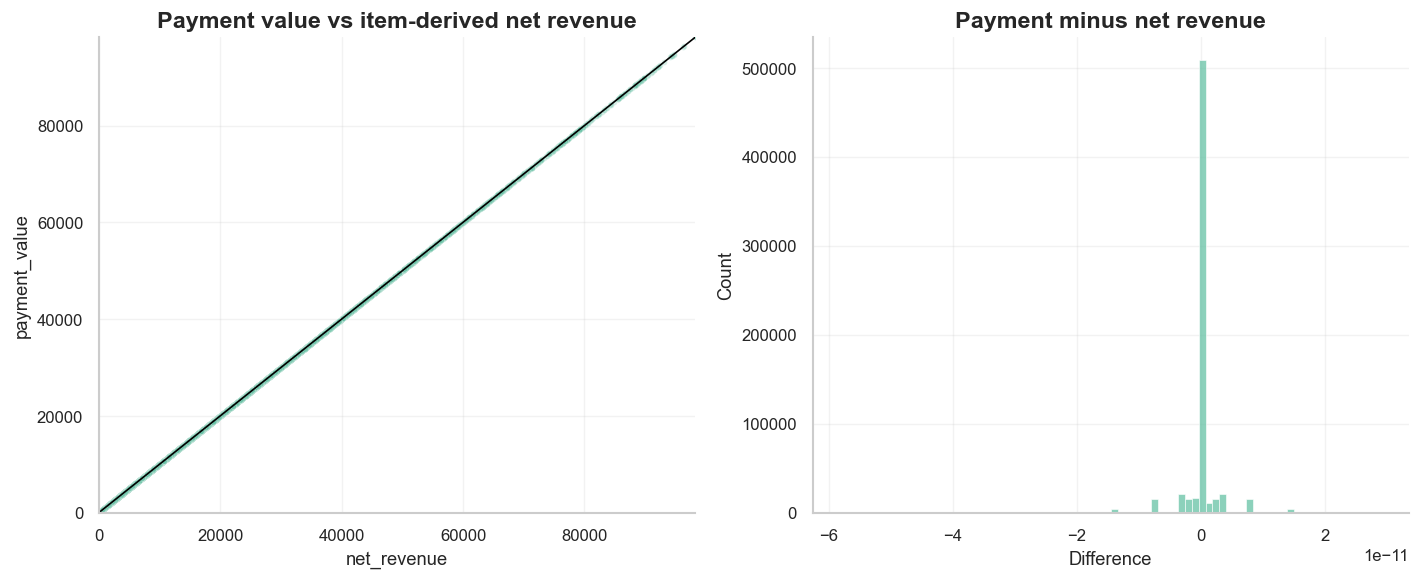

In [60]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sample_payment_proxy = payment_proxy.sample(min(5000, len(payment_proxy)), random_state=42)
sns.scatterplot(data=sample_payment_proxy, x="net_revenue", y="payment_value", alpha=0.25, s=12, ax=axes[0])
limit = sample_payment_proxy[["net_revenue", "payment_value"]].quantile(0.99).max()
axes[0].plot([0, limit], [0, limit], color="black", linewidth=1)
axes[0].set_xlim(0, limit)
axes[0].set_ylim(0, limit)
axes[0].set_title("Payment value vs item-derived net revenue")

sns.histplot(payment_proxy["payment_minus_net_revenue"], bins=80, ax=axes[1])
axes[1].set_title("Payment minus net revenue")
axes[1].set_xlabel("Difference")
plt.tight_layout()

In [61]:
proxy_decision = payment_revenue_proxy_summary(orders_enriched, payments, tolerance=0.01)
proxy_decision

,orders_compared,corr_payment_net_revenue,exact_or_near_match_pct,mean_difference,median_difference,max_abs_difference
0,646945,1.0000,1.0000,-0.0000,0.0000,0.0000


## Save Starter EDA Tables

In [ ]:
report_paths = write_eda_reports(tables)
report_paths

{'eda_table_summary': WindowsPath('D:/NOHOPE/Python/Datathon_VinUni_2026/DATATHON-2026-r1/reports/tables/eda_table_summary.csv'),
 'eda_column_summary': WindowsPath('D:/NOHOPE/Python/Datathon_VinUni_2026/DATATHON-2026-r1/reports/tables/eda_column_summary.csv'),
 'eda_duplicate_key_report': WindowsPath('D:/NOHOPE/Python/Datathon_VinUni_2026/DATATHON-2026-r1/reports/tables/eda_duplicate_key_report.csv'),
 'eda_relationship_checks': WindowsPath('D:/NOHOPE/Python/Datathon_VinUni_2026/DATATHON-2026-r1/reports/tables/eda_relationship_checks.csv'),
 'eda_date_coverage': WindowsPath('D:/NOHOPE/Python/Datathon_VinUni_2026/DATATHON-2026-r1/reports/tables/eda_date_coverage.csv'),
 'eda_customer_cohorts': WindowsPath('D:/NOHOPE/Python/Datathon_VinUni_2026/DATATHON-2026-r1/reports/tables/eda_customer_cohorts.csv'),
 'eda_acquisition_channel_nullness': WindowsPath('D:/NOHOPE/Python/Datathon_VinUni_2026/DATATHON-2026-r1/reports/tables/eda_acquisition_channel_nullness.csv'),
 'eda_revenue_seasonality'

: 